In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
df = pd.read_csv("/healthcare_dataset.csv")
df

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328.0,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265.0,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205.0,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450.0,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458.0,Urgent,2022-10-09,Penicillin,Abnormal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34631,kayla PaTtERSOn,31,Female,B-,Arthritis,2023-08-19,Kim Romero,Bentley Sons and,Medicare,30685.420148,396.0,Urgent,2023-09-08,Paracetamol,Abnormal
34632,NaTALIe wISE,78,Female,A+,Cancer,2020-03-11,Louis Hinton,Ltd Gibson,Medicare,11683.063089,122.0,Emergency,2020-04-08,Ibuprofen,Abnormal
34633,STEPhEN rIos,37,Male,AB+,Asthma,2019-06-28,Michelle Morris,Daniels Ltd,Cigna,1510.921745,398.0,Emergency,2019-07-03,Penicillin,Normal
34634,DOnnA martiN,80,Female,O+,Diabetes,2022-08-06,Marc Nguyen Jr.,Anderson-Jarvis,Aetna,7740.752146,382.0,Elective,2022-08-24,Lipitor,Normal


In [8]:
df.head()

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328.0,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265.0,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205.0,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450.0,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458.0,Urgent,2022-10-09,Penicillin,Abnormal


In [9]:

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34636 entries, 0 to 34635
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Name                34636 non-null  object 
 1   Age                 34636 non-null  int64  
 2   Gender              34636 non-null  object 
 3   Blood Type          34636 non-null  object 
 4   Medical Condition   34636 non-null  object 
 5   Date of Admission   34636 non-null  object 
 6   Doctor              34636 non-null  object 
 7   Hospital            34636 non-null  object 
 8   Insurance Provider  34636 non-null  object 
 9   Billing Amount      34636 non-null  float64
 10  Room Number         34635 non-null  float64
 11  Admission Type      34635 non-null  object 
 12  Discharge Date      34635 non-null  object 
 13  Medication          34635 non-null  object 
 14  Test Results        34635 non-null  object 
dtypes: float64(2), int64(1), object(12)
memory usage: 4.0

In [10]:
billing = df.groupby(["Medical Condition","Insurance Provider"])["Billing Amount"].sum().unstack()
billing

Insurance Provider,Aetna,Blue Cross,Cigna,Medicare,UnitedHealthcare
Medical Condition,,,,,
Arthritis,2.900271e+07,2.996934e+07,2.997690e+07,2.978020e+07,3.033817e+07
Asthma,2.825378e+07,2.854269e+07,3.050457e+07,3.031177e+07,3.048478e+07
Cancer,2.835356e+07,2.812627e+07,2.966137e+07,2.920687e+07,3.002049e+07
Diabetes,3.055933e+07,2.974518e+07,2.926578e+07,3.062974e+07,2.756591e+07
Hypertension,2.997349e+07,3.020411e+07,2.917079e+07,2.838665e+07,3.023638e+07
Obesity,2.897626e+07,3.044884e+07,3.040481e+07,2.923672e+07,2.894362e+07


<Axes: xlabel='Medical Condition'>

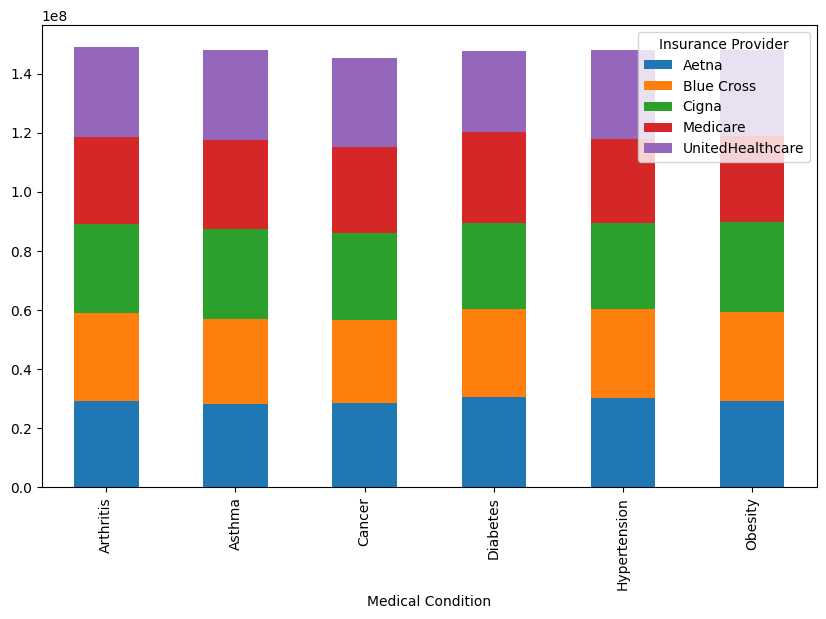

In [11]:
billing.plot(
    kind = "bar",
    stacked = True,
    figsize = (10,6)
)

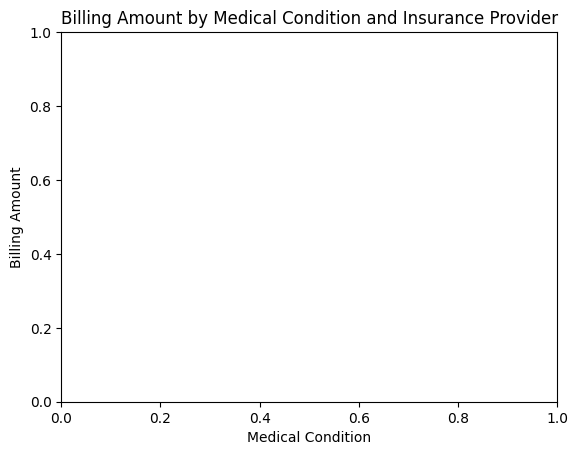

In [12]:
plt.title("Billing Amount by Medical Condition and Insurance Provider")
plt.xlabel("Medical Condition")
plt.ylabel("Billing Amount")
plt.show()

In [14]:
df['Date of Admission'] = pd.to_datetime(df['Date of Admission'])
df['Discharge Date'] = pd.to_datetime(df['Discharge Date'])
df['Hospital_Stay_Days'] = (df['Discharge Date'] - df['Date of Admission']).dt.days
print(df['Billing Amount'].describe())
print(df['Hospital_Stay_Days'].describe())

count    34636.000000
mean     25588.435564
std      14211.630822
min      -1316.618581
25%      13279.808156
50%      25591.515509
75%      37874.997382
max      52373.032374
Name: Billing Amount, dtype: float64
count    34635.000000
mean        15.477609
std          8.646863
min          1.000000
25%          8.000000
50%         15.000000
75%         23.000000
max         30.000000
Name: Hospital_Stay_Days, dtype: float64
